In [1]:
import pandas as pd
import matplotlib.pyplot as plt

email=pd.read_csv("../data/r4.2/email.csv", nrows=300000)
email.head()

,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{R3I7-S4TX96FG-8219JWFF},01/02/2010 07:11:45,LAP0338,PC-5758,Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockhe...,Nathaniel.Hunter.Heath@dtaa.com,NaN,Lynn.Adena.Pratt@dtaa.com,25830,0,middle f2 systems 4 july techniques powerful d...
1,{R0R9-E4GL59IK-2907OSWJ},01/02/2010 07:12:16,MOH0273,PC-6699,Odonnell-Gage@bellsouth.net,NaN,NaN,MOH68@optonline.net,29942,0,the breaking called allied reservations former...
2,{G2B2-A8XY58CP-2847ZJZL},01/02/2010 07:13:00,LAP0338,PC-5758,Penelope_Colon@netzero.com,NaN,NaN,Lynn_A_Pratt@earthlink.net,28780,0,slowly this uncinus winter beneath addition ex...
3,{A3A9-F4TH89AA-8318GFGK},01/02/2010 07:13:17,LAP0338,PC-5758,Judith_Hayden@comcast.net,NaN,NaN,Lynn_A_Pratt@earthlink.net,21907,0,400 other difficult land cirrocumulus powered ...
4,{E8B7-C8FZ88UF-2946RUQQ},01/02/2010 07:13:28,MOH0273,PC-6699,Bond-Raymond@verizon.net;Alea_Ferrell@msn.com;...,NaN,Odonnell-Gage@bellsouth.net,MOH68@optonline.net,17319,0,this kmh october holliswood number advised unu...


In [2]:
# counting users with external email contact records
email["is_external"] = email["to"].str.contains("@(?!company.com)")

external_counts = email.groupby("user")["is_external"].sum()

print(external_counts.sort_values(ascending=False).head())

user
MSS0001    1332
HCS0003     992
HTH0007     991
KWC0004     990
KBP0008     970
Name: is_external, dtype: int64


In [3]:
# counting user with higher attachments shared
attachments = email[email["attachments"] > 0]

attachment_users = attachments.groupby("user").size()

print(attachment_users.sort_values(ascending=False).head())

user
HCS0003    411
TVS0006    400
BTW0005    362
KBP0008    288
QOS0878    262
dtype: int64


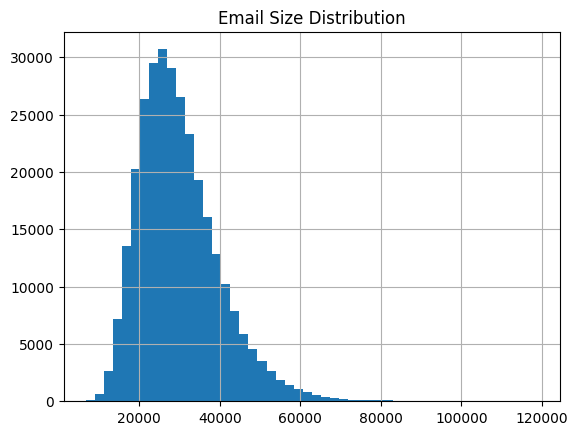

In [4]:
import matplotlib.pyplot as plt

email["size"].hist(bins=50)
plt.title("Email Size Distribution")
plt.show()

<Axes: title={'center': 'daily emails shared '}, xlabel='date'>

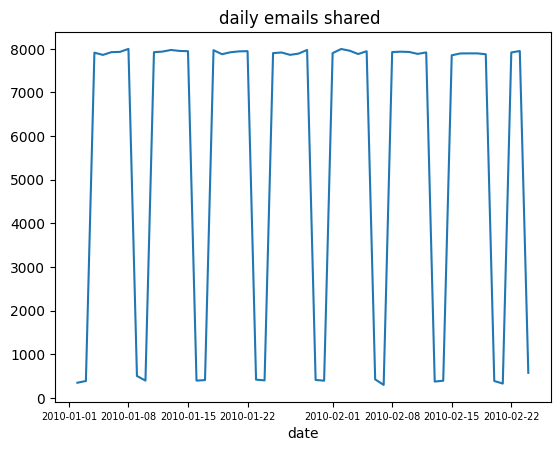

In [5]:
email["date"] = pd.to_datetime(email["date"])
daily_emails = email.groupby(email["date"].dt.date).size()
plt.title('daily emails shared ')
plt.xlabel('frequncy')
plt.xticks(rotation=90,size=7)
daily_emails.plot()

In [6]:
# night time email activity
email["hour"] = email["date"].dt.hour

night_emails = email[(email["hour"] > 18) | (email["hour"] < 6)]

night_users = night_emails.groupby("user").size()

print(night_users.sort_values(ascending=False).head())

user
GTD0116    127
HDD0806    102
HOB0994     99
COF0120     99
HAV0121     91
dtype: int64


In [7]:
#Unique Recipients per User
unique_contacts = email.groupby("user")["to"].nunique()

print(unique_contacts.sort_values(ascending=False).head())

user
MSS0001    489
HTH0007    455
HCS0003    447
KBP0008    441
ATE0869    432
Name: to, dtype: int64


________________________________

anamoly analysis

In [8]:
# Detect email Burst activity Per Hour
email["date"] = pd.to_datetime(email["date"])
email["hour"] = email["date"].dt.floor("h")

burst_activity = email.groupby(["user","hour"]).size().reset_index(name="email_count")
burst_users = burst_activity[burst_activity["email_count"] > 20]

print(burst_users.sort_values("email_count", ascending=False))


          user                hour  email_count
66734  MSS0001 2010-02-10 14:00:00           36
66657  MSS0001 2010-01-14 10:00:00           36
66757  MSS0001 2010-02-18 11:00:00           35
66684  MSS0001 2010-01-25 14:00:00           35
66735  MSS0001 2010-02-11 08:00:00           34
...        ...                 ...          ...
66626  MSS0001 2010-01-06 08:00:00           21
66656  MSS0001 2010-01-13 13:00:00           21
66710  MSS0001 2010-02-03 10:00:00           21
37642  HCS0003 2010-02-10 10:00:00           21
13403  BTW0005 2010-01-13 08:00:00           21

[70 rows x 3 columns]


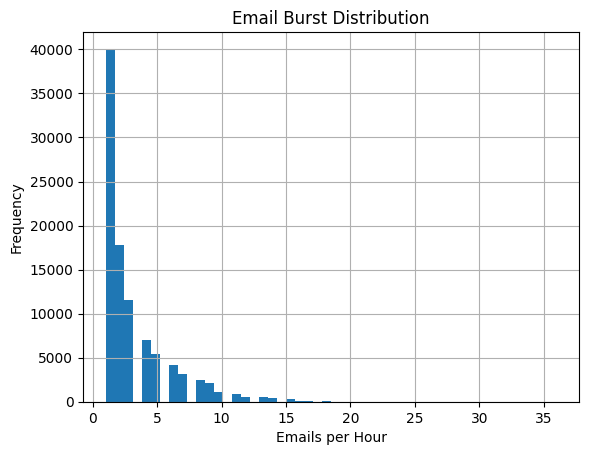

In [9]:
burst_activity["email_count"].hist(bins=50)

plt.title("Email Burst Distribution")
plt.xlabel("Emails per Hour")
plt.ylabel("Frequency")
plt.show()

In [10]:
top_bursts = burst_activity.sort_values("email_count", ascending=False).head(10)

print(top_bursts)


          user                hour  email_count
66734  MSS0001 2010-02-10 14:00:00           36
66657  MSS0001 2010-01-14 10:00:00           36
66684  MSS0001 2010-01-25 14:00:00           35
66757  MSS0001 2010-02-18 11:00:00           35
66735  MSS0001 2010-02-11 08:00:00           34
66667  MSS0001 2010-01-19 08:00:00           30
66721  MSS0001 2010-02-05 10:00:00           29
66751  MSS0001 2010-02-17 09:00:00           28
52217  KBP0008 2010-01-06 09:00:00           27
41547  HTH0007 2010-01-04 08:00:00           27


In [11]:
attachment_burst = email[email["attachments"] > 0]

burst_attach = attachment_burst.groupby(["user","hour"]).size()

print(burst_attach.sort_values(ascending=False).head())

user     hour               
TVS0006  2010-02-22 13:00:00    14
HCS0003  2010-01-05 16:00:00    13
TVS0006  2010-01-08 08:00:00    13
         2010-02-01 10:00:00    13
KBP0008  2010-02-01 07:00:00    13
dtype: int64


In [12]:
external = email[email["is_external"] == True]

burst_external = external.groupby(["user","hour"]).size()

print(burst_external.sort_values(ascending=False).head())

user     hour               
MSS0001  2010-02-10 14:00:00    36
         2010-01-14 10:00:00    36
         2010-01-25 14:00:00    35
         2010-02-18 11:00:00    35
         2010-02-11 08:00:00    34
dtype: int64
